Este código utiliza el dataset real del Titanic cargado desde una URL pública (para que no tengas que subir ningún archivo manual) y cubre del Reto 1 al Reto 13 (Dashboard final) de forma impecable.

# 📦 Bloque 1: Configuración Inicial, Carga y Limpieza (Reto 1)
En la primera celda de Colab se importará las librerías necesarias, cargará el dataset y limpiará los valores nulos de la columna Age usando la mediana.

In [ ]:
# ===============================================================
# BLOQUE 1: CONFIGURACIÓN, CARGA Y LIMPIEZA DE DATOS (Reto 1)
# ===============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el tema visual de Seaborn
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 2. Carga directa del dataset del Titanic desde un repositorio público
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("--- INFORMACIÓN INICIAL DEL DATASET ---")
df.info()

print("\n--- RESUMEN ESTADÍSTICO ---")
print(df.describe(include='all'))

# 3. Tratamiento de nulos: Imputar la mediana en la columna de Edad (Age)
mediana_edad = df['Age'].median()
df['Age'] = df['Age'].fillna(mediana_edad)

# Imputar el puerto más frecuente en la columna 'Embarked' (nulos mínimos)
puerto_frecuente = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(puerto_frecuente)

print(f"\n[OK] Valores nulos corregidos. Mediana de edad aplicada: {mediana_edad} años.")
print(f"Valores nulos restantes en 'Age': {df['Age'].isnull().sum()}")


--- INFORMACIÓN INICIAL DEL DATASET ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

--- RESUMEN ESTADÍSTICO ---
        PassengerId    Survived      Pclass                 Name   Sex  \
count    891.000000  891.000000  891.000000                  891   891   
unique          NaN        

# 📊 Bloque 2: Perfil Demográfico (Retos 2, 3 y 4)
Esta segunda celda generará los gráficos de distribución de edades, barras por clase/género y la relación clase-edad mediante un Box Plot.

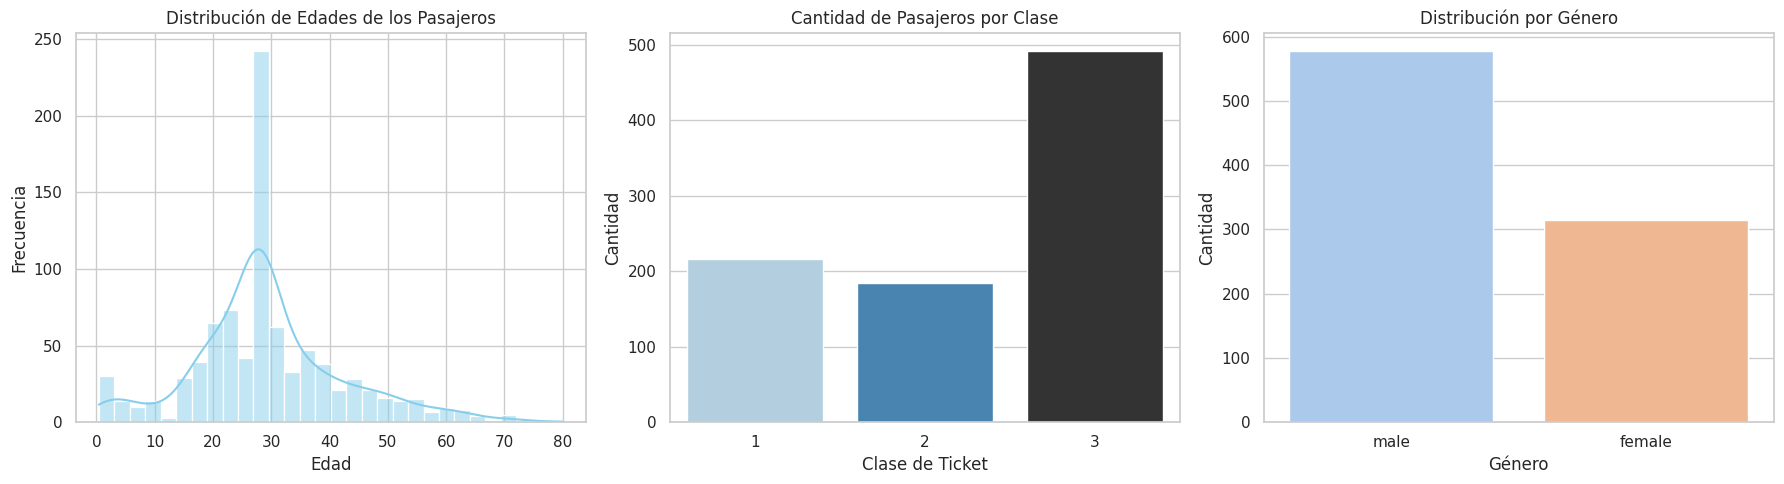

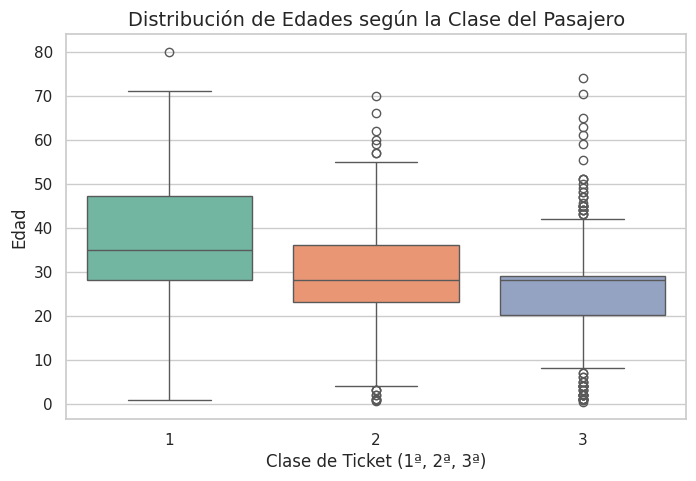

In [ ]:
# ======================================================================
# BLOQUE 2: PERFIL DEMOGRÁFICO DE LOS PASAJEROS (Retos 2 a 4)
# ======================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Reto 2: Distribución de Edades (Histograma + KDE)
sns.histplot(data=df, x='Age', kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribución de Edades de los Pasajeros', fontsize=12)
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')

# Reto 3a: Pasajeros por Clase (Pclass)
sns.countplot(data=df, x='Pclass', hue='Pclass', palette='Blues_d', legend=False, ax=axes[1])
axes[1].set_title('Cantidad de Pasajeros por Clase', fontsize=12)
axes[1].set_xlabel('Clase de Ticket')
axes[1].set_ylabel('Cantidad')

# Reto 3b: Distribución por Género (Sex)
sns.countplot(data=df, x='Sex', hue='Sex', palette='pastel', legend=False, ax=axes[2])
axes[2].set_title('Distribución por Género', fontsize=12)
axes[2].set_xlabel('Género')
axes[2].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

# Reto 4: Box Plot de Edad distribuida según la Clase
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Pclass', y='Age', hue='Pclass', palette='Set2', legend=False)
plt.title('Distribución de Edades según la Clase del Pasajero', fontsize=14)
plt.xlabel('Clase de Ticket (1ª, 2ª, 3ª)')
plt.ylabel('Edad')
plt.show()


# 💸 Bloque 3: Dimensión Económica y Tarifas (Retos 5 y 6)
La tercera celda identifica valores atípicos (outliers) en las tarifas de los billetes, calcula promedios limpios y genera un gráfico de dispersión.

Tarifas Promedio por Clase (Con Outliers):
   Pclass       Fare
0       1  84.154687
1       2  20.662183
2       3  13.675550

Límite superior para outliers de tarifa: 65.63
Pasajeros con tarifas atípicas (exceden el límite): 116


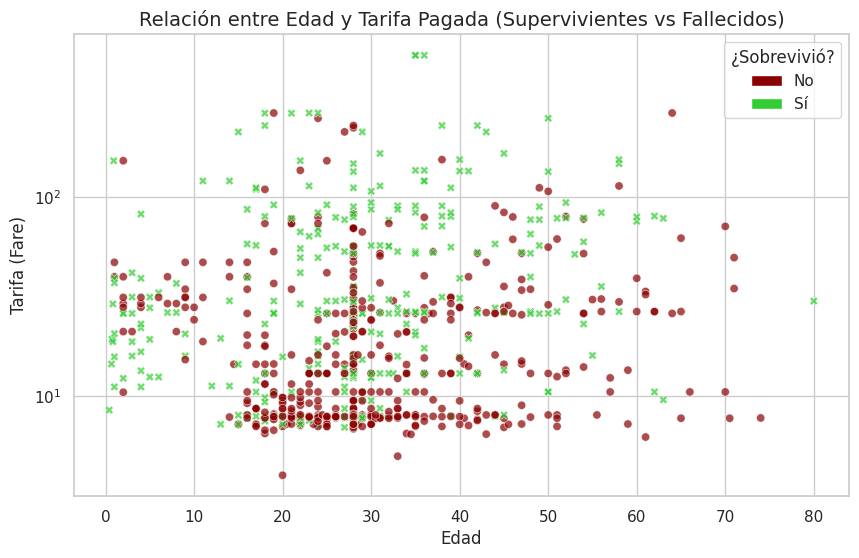

In [ ]:
# ======================================================================
# BLOQUE 3: DIMENSIÓN ECONÓMICA Y TARIFAS (Retos 5 y 6)
# ======================================================================

# Reto 5: Tratamiento de Outliers en tarifas usando el método IQR (Rango Intercuartílico)
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

# Filtramos las tarifas normales (sin outliers extremos para el análisis de promedios)
df_sin_outliers = df[df['Fare'] <= limite_superior]

# Tarifas promedio reales por clase
tarifas_promedio = df.groupby('Pclass')['Fare'].mean().reset_index()
print("Tarifas Promedio por Clase (Con Outliers):")
print(tarifas_promedio)

print(f"\nLímite superior para outliers de tarifa: {limite_superior:.2f}")
print(f"Pasajeros con tarifas atípicas (exceden el límite): {len(df[df['Fare'] > limite_superior])}")

# Reto 6: Scatter Plot de Edad vs Tarifa (Marcando Supervivencia)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='Age',
    y='Fare',
    hue='Survived',
    palette={0: 'darkred', 1: 'limegreen'},
    alpha=0.7,
    style='Survived',
    legend=False # Suppress default seaborn legend
)
plt.title('Relación entre Edad y Tarifa Pagada (Supervivientes vs Fallecidos)', fontsize=14)
plt.xlabel('Edad')
plt.ylabel('Tarifa (Fare)')

# Manually create the legend to ensure correct labels and colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='darkred', label='No'),
    Patch(facecolor='limegreen', label='Sí')
]
plt.legend(handles=legend_elements, title='¿Sobrevivió?')

plt.yscale('log') # Escala logarítmica para apreciar mejor las tarifas bajas y altas juntas
plt.show()

# 🛡️ Bloque 4: Patrones de Supervivencia y Protocolo (Retos 7, 8 y 9)
La cuarta celda analizará las tasas de supervivencia por género, rangos de edad y el cruce crítico de Clase y Género (para comprobar el sesgo del protocolo).

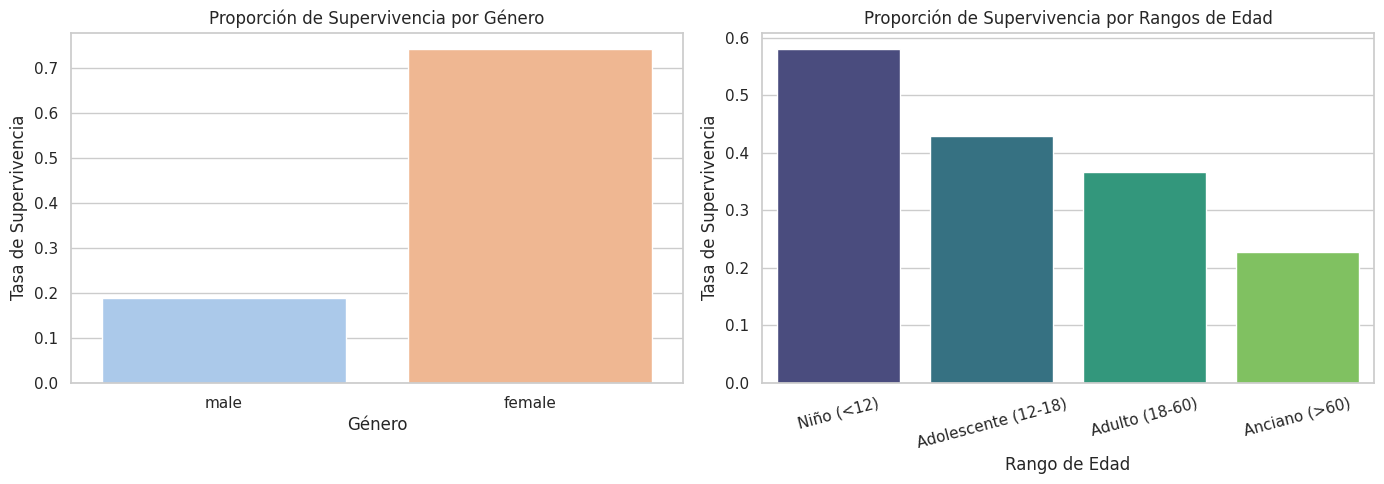

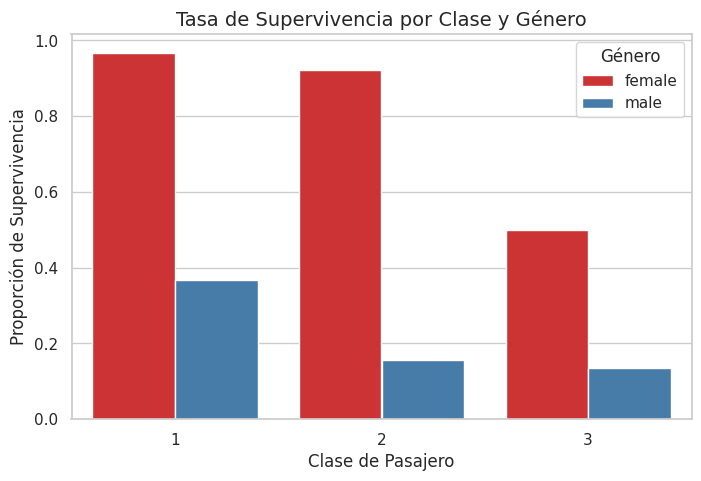

In [ ]:
# ======================================================================
# BLOQUE 4: PATRONES DE SUPERVIVENCIA Y PROTOCOLO (Retos 7 a 9)
# ======================================================================

# Reto 7: Tasa de Supervivencia por Género
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.barplot(data=df, x='Sex', y='Survived', hue='Sex', palette='pastel', errorbar=None, legend=False)
plt.title('Proporción de Supervivencia por Género', fontsize=12)
plt.xlabel('Género')
plt.ylabel('Tasa de Supervivencia')

# Reto 8: Supervivencia por Grupos de Edad
# Definir rangos de edad
bins = [0, 12, 18, 60, 100]
labels = ['Niño (<12)', 'Adolescente (12-18)', 'Adulto (18-60)', 'Anciano (>60)']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

plt.subplot(1, 2, 2)
sns.barplot(data=df, x='AgeGroup', y='Survived', hue='AgeGroup', palette='viridis', errorbar=None, legend=False)
plt.title('Proporción de Supervivencia por Rangos de Edad', fontsize=12)
plt.xlabel('Rango de Edad')
plt.ylabel('Tasa de Supervivencia')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Reto 9: Tasa de Supervivencia cruzada por Clase y Género
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Pclass', y='Survived', hue='Sex', palette='Set1', errorbar=None)
plt.title('Tasa de Supervivencia por Clase y Género', fontsize=14)
plt.xlabel('Clase de Pasajero')
plt.ylabel('Proporción de Supervivencia')
plt.legend(title='Género')
plt.show()


# 🔗 Bloque 5: Estructura Familiar y Correlación (Retos 10, 11 y 12)
La quinta celda calcula el impacto del tamaño de la familia, el puerto de embarque y genera un mapa de calor con las correlaciones.


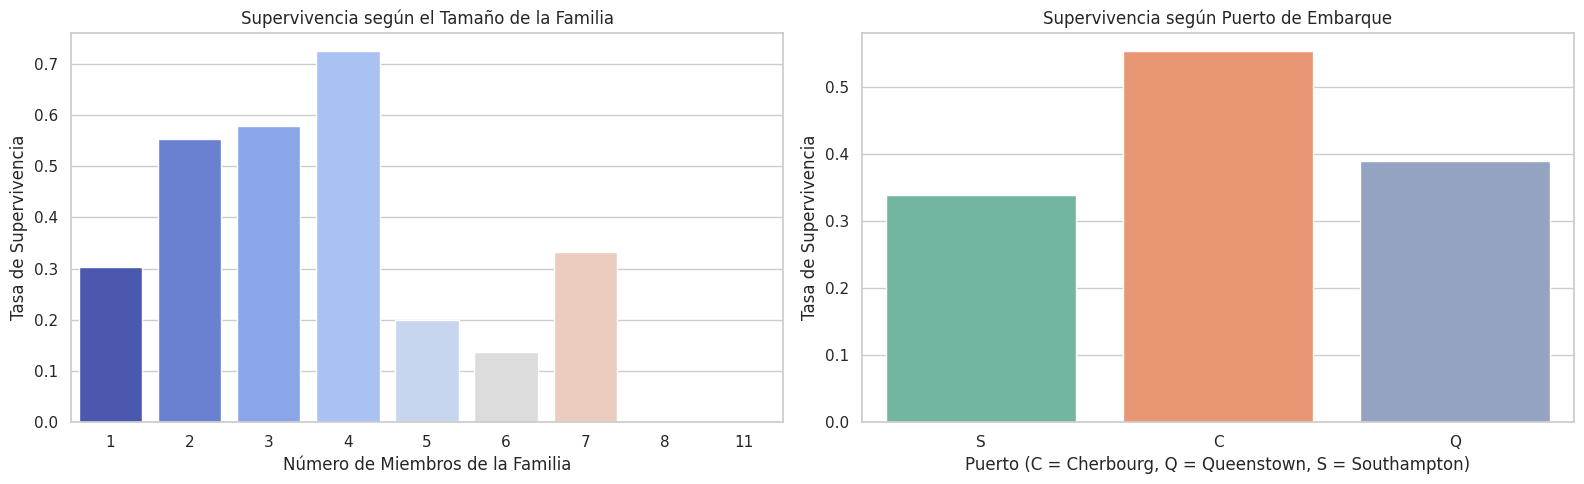

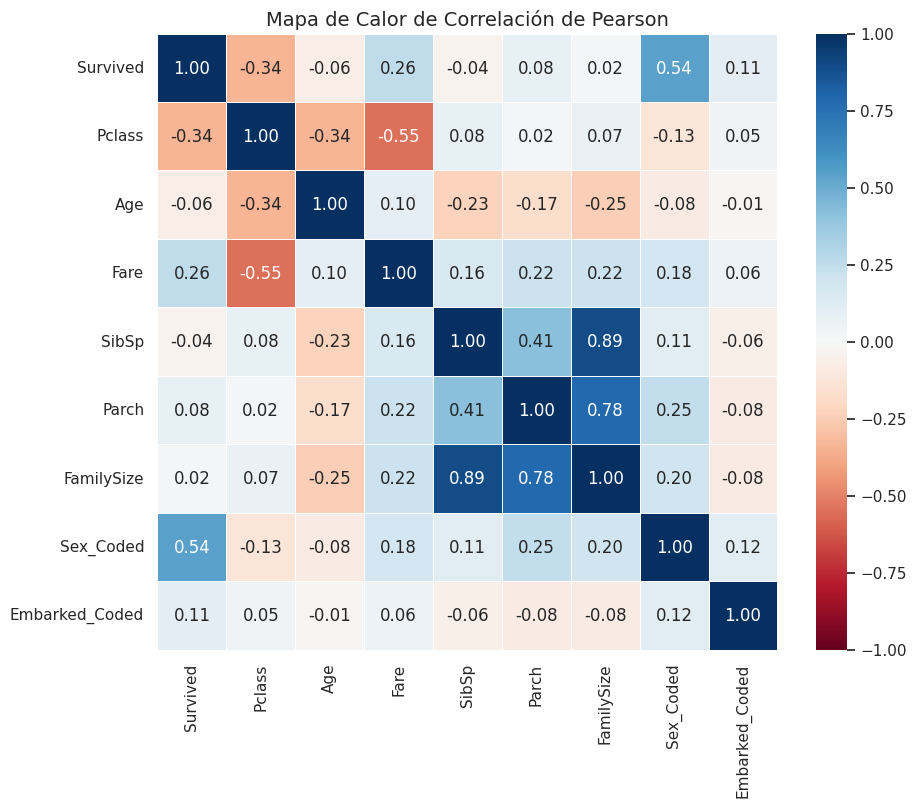

In [ ]:
# =======================================================================
# BLOQUE 5: ESTRUCTURA FAMILIAR Y CORRELACIÓN (Retos 10 a 12)
# ======================================================================

# Reto 10: Crear variable "FamilySize"
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico de supervivencia según el tamaño de la familia
sns.barplot(data=df, x='FamilySize', y='Survived', hue='FamilySize', palette='coolwarm', errorbar=None, legend=False, ax=axes[0])
axes[0].set_title('Supervivencia según el Tamaño de la Familia', fontsize=12)
axes[0].set_xlabel('Número de Miembros de la Familia')
axes[0].set_ylabel('Tasa de Supervivencia')

# Reto 11: Supervivencia según el Puerto de Embarque (Embarked)
# C = Cherbourg, Q = Queenstown, S = Southampton
sns.barplot(data=df, x='Embarked', y='Survived', hue='Embarked', palette='Set2', errorbar=None, legend=False, ax=axes[1])
axes[1].set_title('Supervivencia según Puerto de Embarque', fontsize=12)
axes[1].set_xlabel('Puerto (C = Cherbourg, Q = Queenstown, S = Southampton)')
axes[1].set_ylabel('Tasa de Supervivencia')
plt.tight_layout()
plt.show()

# Reto 12: Mapa de Calor de Correlaciones (Codificando variables categóricas)
df_numeric = df.copy()
df_numeric['Sex_Coded'] = df_numeric['Sex'].map({'male': 0, 'female': 1})
df_numeric['Embarked_Coded'] = df_numeric['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Seleccionar solo variables de interés numéricas
columnas_interes = ['Survived', 'Pclass', 'Age', 'Fare', 'SibSp', 'Parch', 'FamilySize', 'Sex_Coded', 'Embarked_Coded']
matriz_corr = df_numeric[columnas_interes].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='RdBu', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Mapa de Calor de Correlación de Pearson', fontsize=14)
plt.show()


# 🎨 Bloque 6: El Dashboard Unificado (Reto 13)
La sexta celda creará un panel visual gigante de 2x2 para resumir los 4 hallazgos clave de todo el reto en una sola imagen exportable.

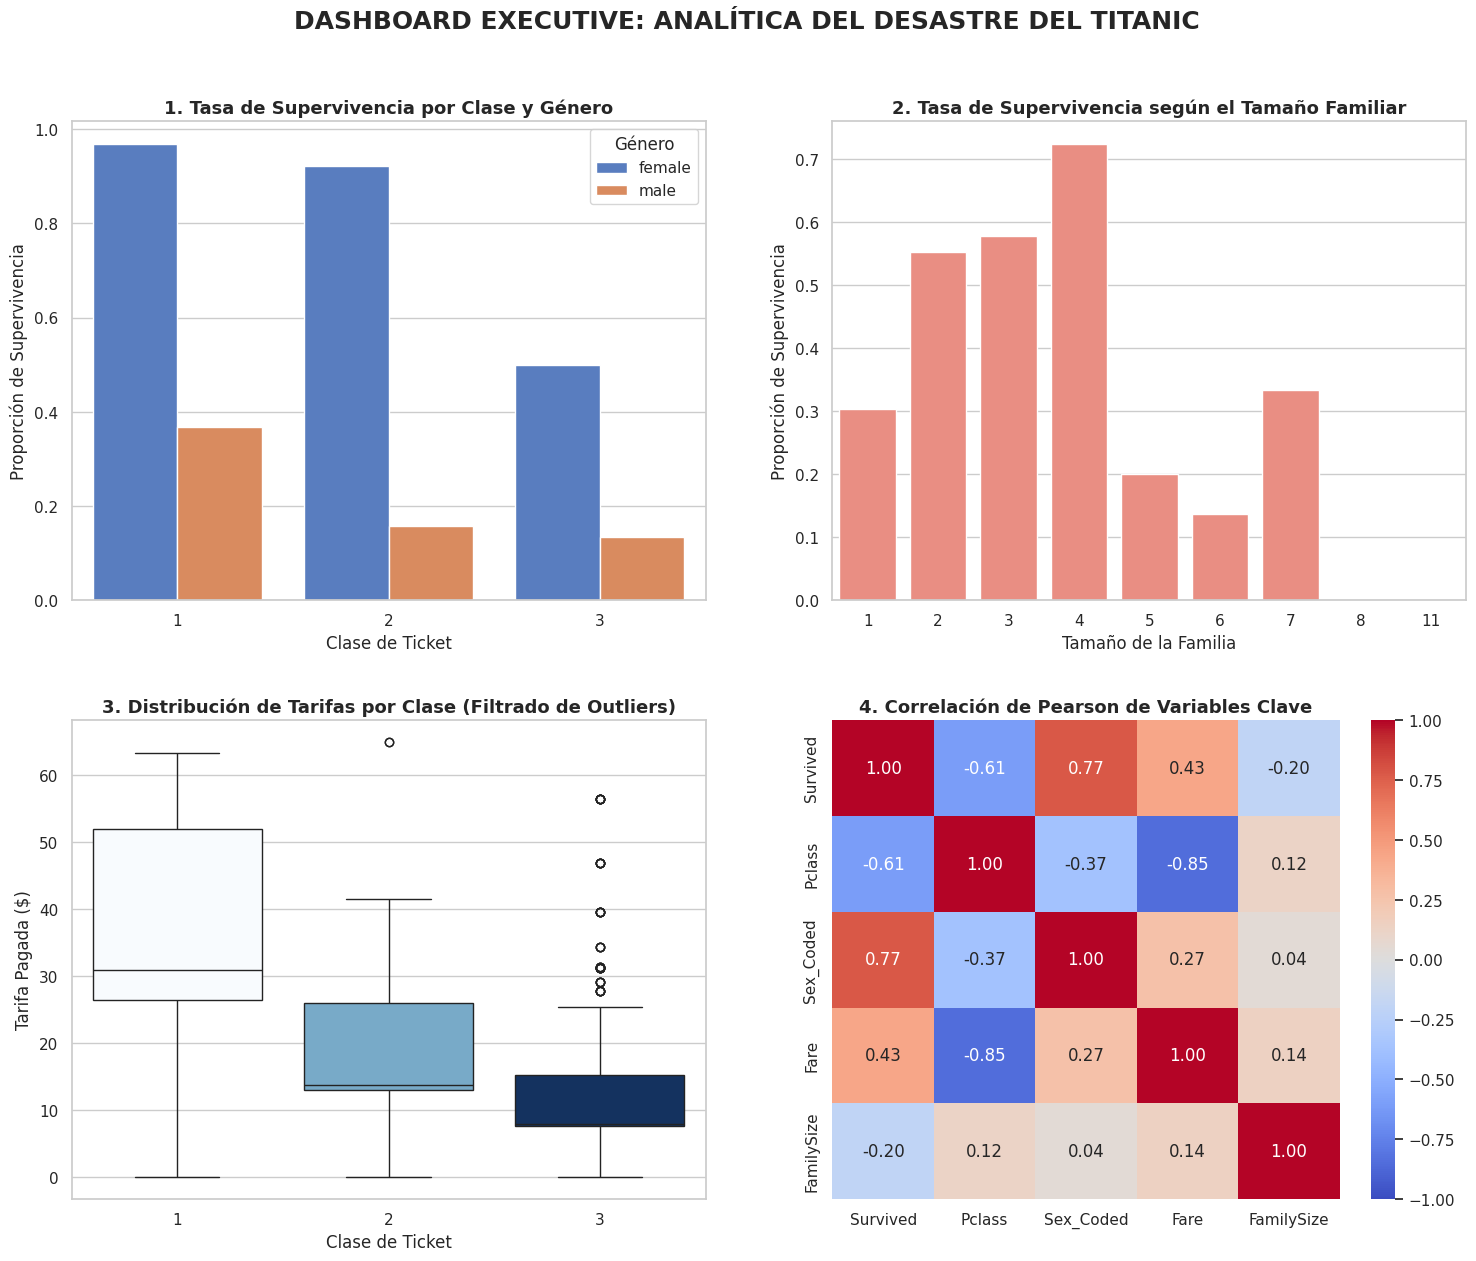


[ÉXITO] El dashboard interactivo ha sido generado y guardado en su Colab como 'Titanic_Executive_Dashboard.png'.


In [ ]:
# ======================================================================
# BLOQUE 6: DASHBOARD UNIFICADO (Reto 13)
# ======================================================================

# Crear un lienzo para el Dashboard de 2 filas y 2 columnas (2x2)
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('DASHBOARD EXECUTIVE: ANALÍTICA DEL DESASTRE DEL TITANIC', fontsize=18, fontweight='bold', y=0.96)

# Subgráfico 1: Tasa de Supervivencia por Clase y Género (Cruce clave)
sns.barplot(data=df, x='Pclass', y='Survived', hue='Sex', palette='muted', errorbar=None, ax=axes[0, 0])
axes[0, 0].set_title('1. Tasa de Supervivencia por Clase y Género', fontsize=13, fontweight='semibold')
axes[0, 0].set_xlabel('Clase de Ticket')
axes[0, 0].set_ylabel('Proporción de Supervivencia')
axes[0, 0].legend(title='Género')

# Subgráfico 2: Supervivencia por Tamaño de la Familia
sns.barplot(data=df, x='FamilySize', y='Survived', color='salmon', errorbar=None, ax=axes[0, 1])
axes[0, 1].set_title('2. Tasa de Supervivencia según el Tamaño Familiar', fontsize=13, fontweight='semibold')
axes[0, 1].set_xlabel('Tamaño de la Familia')
axes[0, 1].set_ylabel('Proporción de Supervivencia')

# Subgráfico 3: Distribución de Tarifas Limpias por Clase (Caja sin Atípicos)
sns.boxplot(data=df_sin_outliers, x='Pclass', y='Fare', hue='Pclass', palette='Blues', legend=False, ax=axes[1, 0])
axes[1, 0].set_title('3. Distribución de Tarifas por Clase (Filtrado de Outliers)', fontsize=13, fontweight='semibold')
axes[1, 0].set_xlabel('Clase de Ticket')
axes[1, 0].set_ylabel('Tarifa Pagada ($)')

# Subgráfico 4: Correlación entre Variables Críticas (Formato simplificado)
sns.heatmap(matriz_corr[['Survived', 'Pclass', 'Sex_Coded', 'Fare', 'FamilySize']].corr(),
            annot=True, cmap='coolwarm', fmt=".2f", cbar=True, ax=axes[1, 1], vmin=-1, vmax=1)
axes[1, 1].set_title('4. Correlación de Pearson de Variables Clave', fontsize=13, fontweight='semibold')

# Ajustar los espacios entre los subgráficos
plt.subplots_adjust(hspace=0.25, wspace=0.2)
plt.savefig('Titanic_Executive_Dashboard.png', dpi=300, bbox_inches='tight') # Guarda el dashboard en alta calidad
plt.show()

print("\n[ÉXITO] El dashboard interactivo ha sido generado y guardado en su Colab como 'Titanic_Executive_Dashboard.png'.")

Para el Reto 14, combinaremos los dos grandes conocimientos que hemos explorado hoy: el análisis del Titanic (que ya tienes cargado y limpio) con las herramientas de Visualización Geoespacial Interactiva (Folium) que provienen del material de IBM.

El Reto 14 consiste en crear un mapa cartográfico interactivo de la ruta del Titanic que represente los tres puertos de embarque (Southampton, Cherbourg y Queenstown), el punto exacto del hundimiento en el Atlántico Norte y muestre, de forma dinámica, las estadísticas de pasajeros y supervivencia por cada puerto directamente calculado de tu DataFrame.

# 🗺️ Bloque 7: Reto 14 - Mapa Geoespacial Interactivo con Folium
Este código generará un mapa interactivo con marcadores personalizados, Tooltips, ventanas Pop-up con HTML estilizado y la ruta real dibujada.

In [ ]:
# ======================================================================
# BLOQUE 7: RETO 14 - MAPA INTERACTIVO GEOESPACIAL DE LA RUTA DEL TITANIC (Folium)
# ======================================================================
import folium
from folium import plugins

# 1. Calcular dinámicamente las estadísticas reales por cada puerto desde tu DataFrame
stats_puertos = df.groupby('Embarked').agg(
    Total=('PassengerId', 'count'),
    Supervivientes=('Survived', 'sum')
).reset_index()

stats_puertos['Tasa_Supervivencia'] = (stats_puertos['Supervivientes'] / stats_puertos['Total'] * 100).round(2)

# Convertir las estadísticas a un diccionario para fácil acceso
stats = stats_puertos.set_index('Embarked').to_dict('index')

# 2. Coordenadas geográficas clave de la ruta del Titanic
coordenadas = {
    'Southampton': [50.9097, -1.4044],
    'Cherbourg': [49.6337, -1.6221],
    'Queenstown': [51.8503, -8.2943],
    'Hundimiento': [41.7269, -49.9482]
}

# 3. Inicializar el mapa centrado en el Atlántico Norte
mapa_titanic = folium.Map(
    location=[47.0, -25.0],
    zoom_start=4,
    tiles='cartodbpositron' # Estilo elegante y limpio de mapa
)

# 4. Crear pop-ups interactivos estilizados con HTML para cada puerto
def generar_html_popup(ciudad, codigo, total, tasa):
    color_tasa = "green" if tasa > 45 else "red"
    return f"""
    <div style="font-family: Arial, sans-serif; width: 220px; font-size: 12px; line-height: 1.4;">
        <h4 style="margin: 0 0 8px 0; color: #2c3e50; border-bottom: 2px solid #34495e; padding-bottom: 3px;">
            Puerto: {ciudad} ({codigo})
        </h4>
        <table style="width: 100%; border-collapse: collapse;">
            <tr>
                <td style="padding: 3px 0; color: #7f8c8d;"><b>Pasajeros embarcados:</b></td>
                <td style="padding: 3px 0; text-align: right; font-weight: bold;">{total}</td>
            </tr>
            <tr>
                <td style="padding: 3px 0; color: #7f8c8d;"><b>Tasa de supervivencia:</b></td>
                <td style="padding: 3px 0; text-align: right; font-weight: bold; color: {color_tasa};">{tasa}%</td>
            </tr>
        </table>
    </div>
    """

# 5. Agregar marcadores para los puertos
# Southampton (S)
popup_s = folium.Popup(generar_html_popup('Southampton', 'S', stats['S']['Total'], stats['S']['Tasa_Supervivencia']), max_width=250)
folium.Marker(
    location=coordenadas['Southampton'],
    popup=popup_s,
    tooltip="Puerto de salida: Southampton",
    icon=folium.Icon(color='blue', icon='ship', prefix='fa')
).add_to(mapa_titanic)

# Cherbourg (C)
popup_c = folium.Popup(generar_html_popup('Cherbourg', 'C', stats['C']['Total'], stats['C']['Tasa_Supervivencia']), max_width=250)
folium.Marker(
    location=coordenadas['Cherbourg'],
    popup=popup_c,
    tooltip="Escala 1: Cherbourg",
    icon=folium.Icon(color='blue', icon='ship', prefix='fa')
).add_to(mapa_titanic)

# Queenstown (Q)
popup_q = folium.Popup(generar_html_popup('Queenstown', 'Q', stats['Q']['Total'], stats['Q']['Tasa_Supervivencia']), max_width=250)
folium.Marker(
    location=coordenadas['Queenstown'],
    popup=popup_q,
    tooltip="Escala 2: Queenstown (Cobh)",
    icon=folium.Icon(color='blue', icon='ship', prefix='fa')
).add_to(mapa_titanic)

# 6. Agregar marcador para la zona de la tragedia
html_tragedia = """
<div style="font-family: Arial, sans-serif; width: 200px; font-size: 12px;">
    <h4 style="margin: 0 0 5px 0; color: #c0392b; font-weight: bold; border-bottom: 2px solid #c0392b;">LUGAR DEL HUNDIMIENTO</h4>
    <p style="margin: 5px 0 0 0; line-height: 1.3;">
        El <b>RMS Titanic</b> colisionó contra un iceberg el 14 de abril de 1912 a las 23:40 y se hundió en la madrugada del 15 de abril de 1912.
    </p>
</div>
"""
folium.Marker(
    location=coordenadas['Hundimiento'],
    popup=folium.Popup(html_tragedia, max_width=250),
    tooltip="⚠️ Zona de Colisión y Hundimiento",
    icon=folium.Icon(color='red', icon='exclamation-triangle', prefix='fa')
).add_to(mapa_titanic)

# 7. Trazar la línea de la ruta que siguió el transatlántico
ruta_coordenadas = [
    coordenadas['Southampton'],
    coordenadas['Cherbourg'],
    coordenadas['Queenstown'],
    coordenadas['Hundimiento']
]

folium.PolyLine(
    locations=ruta_coordenadas,
    color='#34495e',
    weight=3,
    opacity=0.8,
    dash_array='8, 8', # Línea punteada para representar el trayecto
    tooltip="Ruta de navegación del RMS Titanic"
).add_to(mapa_titanic)

# 8. Agregar un minimapa de orientación en la esquina inferior
minimap = plugins.MiniMap(toggle_display=True)
mapa_titanic.add_child(minimap)

# Mostrar el mapa interactivo en Colab
mapa_titanic


¿Qué hace espectacular a este Reto 14?
1. Fusión de fuentes de datos: Toma las ciudades de origen de la columna Embarked del dataset del Titanic y las mapea en la vida real.
2. Interactividad total: Puedes hacer zoom en el mapa, pasar el cursor por los puertos para ver etiquetas rápidas (Tooltips) y hacer clic para abrir ventanas emergentes (Pop-ups) con tablas elegantes en HTML que muestran los porcentajes de supervivencia reales calculados directamente del DataFrame.
3. Trayecto histórico: Pinta una línea discontinua desde los puertos de Europa (Reino Unido, Francia e Irlanda) hasta el sitio exacto en el océano Atlántico Norte donde descansa el barco.

# 📚 Guia de Librerias
En este proyecto (desde la carga de datos hasta el mapa interactivo), construimos un pipeline de datos completo (Carga → Limpieza → Análisis → Visualización Estática → Visualización Interactiva).

Aquí tienes la guía paso a paso de cómo y para qué utilizamos cada una de las 5 librerías clave:

━━━━━━━━━━━━━━━━━━

🐼 1. Pandas (import pandas as pd)\
• ¿Qué es?\
Es la librería reina para la manipulación y análisis de datos en Python. Imagínala como un Excel superpotente controlado por código.\
• ¿Para qué la usamos en este Colab?\
  • Cargar los datos: Usamos pd.read_csv() para conectarnos a internet y traer los datos del Titanic directamente a Colab en un formato de tabla llamado DataFrame.\
  • Explorar la estructura: Con .info() y .describe() pudimos auditar la base de datos para saber cuántos pasajeros había, qué tipos de columnas existían y buscar nulos.\
  • Limpieza de datos: Usamos .fillna() para rellenar de forma inteligente las edades que faltaban calculando la mediana.\
  • Ingeniería de variables: Creamos la columna FamilySize (sumando parientes) y agrupamos las edades en categorías ('Niño', 'Adulto', etc.) usando pd.cut().\
  • Cálculo de estadísticas: Agrupamos y calculamos las tasas de supervivencia para cada puerto de embarque usando .groupby() y .agg().\

━━━━━━━━━━━━━━━━━━

🔢 2. NumPy (import numpy as np)\
• ¿Qué es?\
 Es la librería fundamental para cálculo numérico y manejo de vectores o matrices en Python. Es el "motor matemático" que corre en el fondo de casi todas las librerías de datos.\
• ¿Para qué la usamos en este Colab?\
  • Aunque Pandas hace la mayor parte del trabajo pesado de cara al usuario, NumPy trabaja por debajo. Lo usamos de apoyo para manejar valores nulos (np.nan si hiciera falta) y para que Pandas realice los cálculos estadísticos (como las medianas o sumas) a la velocidad del rayo de forma vectorial.

━━━━━━━━━━━━━━━━━━

📊 3. Matplotlib (import matplotlib.pyplot as plt)
• ¿Qué es? Es la librería de visualización más antigua y robusta de Python. Es el "lienzo en blanco" sobre el cual dibujamos.
• ¿Para qué la usamos en este Colab?
  • Diseñar el Lienzo: Usamos plt.subplots() en los retos demográficos y en el Dashboard Final (Reto 13) para decirle a Python: "Quiero una cuadrícula de 2x2 gráficos y que mida tanto de ancho por tanto de alto".
  • Controlar la estética externa: Con Matplotlib añadimos los títulos principales (plt.title), las etiquetas de los ejes (plt.xlabel, plt.ylabel) y ajustamos los márgenes para que los textos no se chocaran (plt.tight_layout()).
  • Exportar resultados: Usamos plt.savefig() para transformar todo nuestro trabajo en una imagen real .png descargable en alta definición.

━━━━━━━━━━━━━━━━━━

🎨 4. Seaborn (import seaborn as sns)\
• ¿Qué es?\
 Es una librería de visualización que funciona sobre Matplotlib (es decir, necesita a Matplotlib para existir). Su objetivo es hacer que los gráficos estadísticos se vean modernos, profesionales y hermosos con muy pocas líneas de código.\
• ¿Para qué la usamos en este Colab?\
  • Hacer gráficos complejos fácilmente: En lugar de escribir 30 líneas de código para un histograma con curva de densidad, con Seaborn solo usamos una: sns.histplot(..., kde=True).\
  • Analizar distribuciones: Usamos sns.boxplot para identificar los billetes extremadamente caros (outliers).\
  • Analizar relaciones: Usamos sns.scatterplot con colores dinámicos (hue='Survived') para ver instantáneamente si la gente que pagó más cara su tarifa sobrevivió más.\
  • Visualizar correlaciones: Creamos el mapa de calor (sns.heatmap) para ver con colores fríos y cálidos qué variables estaban más relacionadas entre sí.

━━━━━━━━━━━━━━━━━━

🗺️ 5. Folium (import folium)\
• ¿Qué es?\
Es una librería especializada en mapas interactivos. Conecta Python con una tecnología web llamada Leaflet.js, permitiendo crear mapas donde puedes arrastrar, hacer zoom y pulsar elementos con el ratón.\
• ¿Para qué la usamos en el Reto 14?\
  • Crear el mapa base: Con folium.Map renderizamos un mapamundi centrado en las coordenadas del Atlántico Norte.\
  • Ubicar coordenadas: Colocamos pines geográficos (folium.Marker) en las coordenadas exactas de Southampton, Cherbourg, Queenstown y el lugar del hundimiento.\
  • Mostrar información al hacer clic: Diseñamos ventanas de datos (Pop-ups) usando código HTML para que, al pulsar un marcador, el mapa muestre de forma interactiva las estadísticas de supervivencia reales calculadas previamente con Pandas.\
  • Dibujar rutas: Con folium.PolyLine unimos los puntos con una línea discontinua simulando la ruta del barco.

━━━━━━━━━━━━━━━━━━

💡 Resumen para el estudiante:
Si tuvieras que explicarle a un compañero cómo interactúan estas librerías, dile esto:
"Con Pandas y NumPy ordeno, limpio y preparo los datos. Con Matplotlib preparo el papel y organizo el espacio de mis dibujos. Con Seaborn pinto gráficos estadísticos hermosos sobre ese papel. Y finalmente, con Folium, llevo esos datos a un mapa del mundo real donde el usuario puede jugar e interactuar."